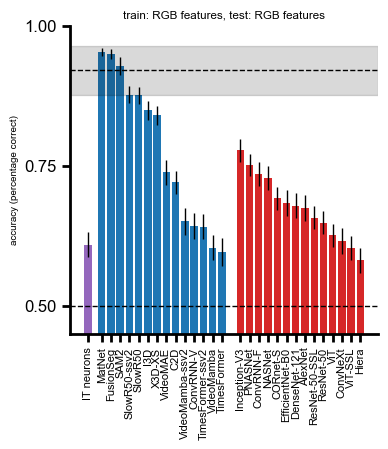

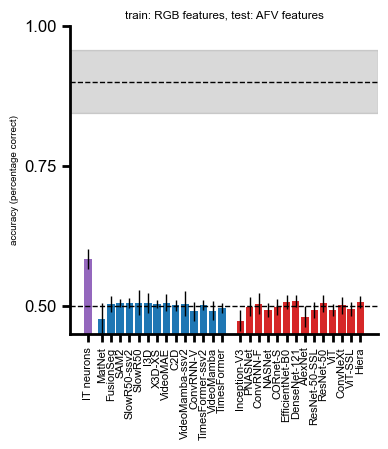

In [9]:
import sys
sys.path.append('../')

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import cm

from utils.plot_utils import journal_figure_pdf

import scienceplots

plt.style.use(['nature'])

# Define static (image-based) models with their properties: [type, color, label]
static_models = {
    "images_moving1_alexnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'AlexNet'], 
    "images_moving1_convnext_features_srp_1000_10.h5" : ['f', 'tab:red', 'ConvNeXt'], 
    "images_moving1_densenet121_features_srp_1000_10.h5" : ['f', 'tab:red', 'DenseNet-121'], 
    "images_moving1_efficientnet_b0_features_srp_1000_10.h5" : ['f', 'tab:red', 'EfficientNet-B0'], 
    "images_moving1_hiera_features_srp_1000_10.h5" : ['f', 'tab:red', 'Hiera'], 
    "images_moving1_inception_v3_features_srp_1000_10.h5" : ['f', 'tab:red', 'Inception-V3'], 
    "images_moving1_pnasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'PNASNet'], 
    "images_moving1_resnet50_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50'], 
    "images_moving1_resnet50_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ResNet-50-SSL'], 
    "images_moving1_vit_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT'], 
    "images_moving1_vit_ssl_features_srp_1000_10.h5" : ['f', 'tab:red', 'ViT-SSL'], 
    "images_moving1_nasnet_features_srp_1000_10.h5" : ['f', 'tab:red', 'NASNet'], 
    "images_moving1_rgc_intermediate_features_ff_srp_1000_10.h5" : ['ri', 'tab:red', 'ConvRNN-F'],
    "images_moving1_CORnet-S_IT_features_srp_1000_10.h5" : ['ri', 'tab:red', 'CORnet-S'],
}

# Define dynamic (video-based) models with their properties: [type, color, label]
dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_features_srp_1000_10.h5" : ['d', 'tab:blue', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_features_srp_1000_10.h5" : ['d', 'tab:blue', 'FusionSeg'],
    "images_moving1_rgc_intermediate_features_srp_1000_10.h5" : ['rv', 'tab:blue', 'ConvRNN-V'],
}

# Path to folder containing model classification scores
scores_path = '../../scores/figure3'

# Combine static and dynamic models
models = {**static_models, **dynamic_models}

# Initialize lists to store results for RGB->AFV decoding task
values_rgb2afv_rgb = []
errors_rgb2afv_rgb = []
values_rgb2afv_afv = []
errors_rgb2afv_afv = []

vid_values_rgb2afv_rgb = []
vid_values_rgb2afv_afv = []

# Initialize lists to store results for AFV->RGB decoding task
values_afv2rgb_rgb = []
errors_afv2rgb_rgb = []
values_afv2rgb_afv = []
errors_afv2rgb_afv = []

vid_values_afv2rgb_rgb = []
vid_values_afv2rgb_afv = []

# ============================================================================
# PROCESS RGB->AFV DECODING RESULTS FOR EACH MODEL
# ============================================================================
methods_names = list(models.keys())
for name in methods_names:
    
    # Load RGB->AFV decoding results
    file_rgb_rgb2afv = h5py.File(f'{scores_path}/{name}/decode_obj_dir_rnn_rgb2afv.h5', 'r')

    # Process i1 scores for original (RGB) features
    i1_per_time_rgb2afv_rgb = np.array(file_rgb_rgb2afv[f'i1_all_rgb'])
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    i1_per_time_rgb2afv_rgb = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    
    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_rgb_m = np.nanmean(i1_per_time_rgb2afv_rgb, axis=-1)
    max_id = np.argmax(i1_per_time_rgb2afv_rgb_m)
    i1_per_time_rgb2afv_rgb = i1_per_time_rgb2afv_rgb[max_id]

    # Process i1 scores for AFV features
    i1_per_time_rgb2afv_afv = np.array(file_rgb_rgb2afv[f'i1_all_afv'])
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    i1_per_time_rgb2afv_afv = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)

    # Find best performing video and extract its scores
    i1_per_time_rgb2afv_afv_m = np.nanmean(i1_per_time_rgb2afv_afv, axis=-1)
    max_id = np.argmax(i1_per_time_rgb2afv_afv_m)
    i1_per_time_rgb2afv_afv = i1_per_time_rgb2afv_afv[max_id]

    # Load AFV->RGB decoding results
    file_rgb_afv2rgb = h5py.File(f'{scores_path}/{name}/decode_obj_dir_rnn_afv2rgb.h5', 'r')
    
    # Process i1 scores for original (RGB) features
    i1_per_time_afv2rgb_rgb = np.array(file_rgb_afv2rgb[f'i1_all_rgb'])
    i1_per_time_afv2rgb_rgb = np.nanmean(i1_per_time_afv2rgb_rgb, axis=-1)
    i1_per_time_afv2rgb_rgb = np.nanmean(i1_per_time_afv2rgb_rgb, axis=0)
    
    i1_per_time_afv2rgb_rgb_m = np.nanmean(i1_per_time_afv2rgb_rgb, axis=-1)
    max_id = np.argmax(i1_per_time_afv2rgb_rgb_m)
    i1_per_time_afv2rgb_rgb = i1_per_time_afv2rgb_rgb[max_id]

    # Process i1 scores for AFV features
    i1_per_time_afv2rgb_afv = np.array(file_rgb_afv2rgb[f'i1_all_afv'])
    i1_per_time_afv2rgb_afv = np.nanmean(i1_per_time_afv2rgb_afv, axis=-1)
    i1_per_time_afv2rgb_afv = np.nanmean(i1_per_time_afv2rgb_afv, axis=0)
    
    i1_per_time_afv2rgb_afv_m = np.nanmean(i1_per_time_afv2rgb_afv, axis=-1)
    max_id = np.argmax(i1_per_time_afv2rgb_afv_m)
    i1_per_time_afv2rgb_afv = i1_per_time_afv2rgb_afv[max_id]

    # Calculate mean and standard error for RGB->AFV task (original features)
    i1_per_time_rgb2afv_rgb_mean = np.nanmean(i1_per_time_rgb2afv_rgb, axis=0)
    i1_per_time_rgb2afv_rgb_se = np.nanstd(i1_per_time_rgb2afv_rgb, axis=0) / np.sqrt(i1_per_time_rgb2afv_rgb.shape[0])

    values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_mean)
    errors_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb_se)

    # Calculate mean and standard error for RGB->AFV task (AFV features)
    i1_per_time_rgb2afv_afv_mean = np.nanmean(i1_per_time_rgb2afv_afv, axis=0)
    i1_per_time_rgb2afv_afv_se = np.nanstd(i1_per_time_rgb2afv_afv, axis=0) / np.sqrt(i1_per_time_rgb2afv_afv.shape[0])

    values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_mean)
    errors_rgb2afv_afv.append(i1_per_time_rgb2afv_afv_se)

    vid_values_rgb2afv_rgb.append(i1_per_time_rgb2afv_rgb)  
    vid_values_rgb2afv_afv.append(i1_per_time_rgb2afv_afv)

    # Calculate mean and standard error for AFV->RGB task (original features)
    i1_per_time_afv2rgb_rgb_mean = np.nanmean(i1_per_time_afv2rgb_rgb, axis=0)
    i1_per_time_afv2rgb_rgb_se = np.nanstd(i1_per_time_afv2rgb_rgb, axis=0) / np.sqrt(i1_per_time_afv2rgb_rgb.shape[0])

    values_afv2rgb_rgb.append(i1_per_time_afv2rgb_rgb_mean)
    errors_afv2rgb_rgb.append(i1_per_time_afv2rgb_rgb_se)

    # Calculate mean and standard error for AFV->RGB task (AFV features)
    i1_per_time_afv2rgb_afv_mean = np.nanmean(i1_per_time_afv2rgb_afv, axis=0)
    i1_per_time_afv2rgb_afv_se = np.nanstd(i1_per_time_afv2rgb_afv, axis=0) / np.sqrt(i1_per_time_afv2rgb_afv.shape[0])

    values_afv2rgb_afv.append(i1_per_time_afv2rgb_afv_mean)
    errors_afv2rgb_afv.append(i1_per_time_afv2rgb_afv_se)

    vid_values_afv2rgb_rgb.append(i1_per_time_afv2rgb_rgb)  
    vid_values_afv2rgb_afv.append(i1_per_time_afv2rgb_afv)

# ============================================================================
# PROCESS IT NEURON DECODING RESULTS (RGB->AFV)
# ============================================================================
file_rgb_rgb2afv = h5py.File(f'{scores_path}/IT_neurons/decode_IT_obj_dir_rnn_rgb2afv.h5', 'r')
accuracy_per_time_rgb2afv_rgb = np.array(file_rgb_rgb2afv['i1_orig_all'])
accuracy_per_time_rgb2afv_rgb = np.nanmean(accuracy_per_time_rgb2afv_rgb, axis=0)

accuracy_per_time_rgb2afv_afv = np.array(file_rgb_rgb2afv['i1_afv_all'])
accuracy_per_time_rgb2afv_afv = np.nanmean(accuracy_per_time_rgb2afv_afv, axis=0)

# Extract best video and compute statistics for RGB features
accuracy_per_time_rgb2afv_rgb_m = np.nanmean(accuracy_per_time_rgb2afv_rgb, axis=-1)
best_idx = np.argmax(accuracy_per_time_rgb2afv_rgb_m)
accuracy_per_time_rgb2afv_rgb_vid = accuracy_per_time_rgb2afv_rgb[best_idx]
accuracy_per_time_rgb2afv_rgb_m = np.nanmean(accuracy_per_time_rgb2afv_rgb[best_idx])
accuracy_per_time_rgb2afv_rgb_se = np.nanstd(accuracy_per_time_rgb2afv_rgb[best_idx]) / np.sqrt(accuracy_per_time_rgb2afv_rgb.shape[1])

# Extract best video and compute statistics for AFV features
accuracy_per_time_rgb2afv_afv_m = np.nanmean(accuracy_per_time_rgb2afv_afv, axis=-1)
best_idx = np.argmax(accuracy_per_time_rgb2afv_afv_m)
accuracy_per_time_rgb2afv_afv_vid = accuracy_per_time_rgb2afv_afv[best_idx]
accuracy_per_time_rgb2afv_afv_m = np.nanmean(accuracy_per_time_rgb2afv_afv[best_idx])
accuracy_per_time_rgb2afv_afv_se = np.nanstd(accuracy_per_time_rgb2afv_afv[best_idx]) / np.sqrt(accuracy_per_time_rgb2afv_afv.shape[1])

# ============================================================================
# PROCESS IT NEURON DECODING RESULTS (AFV->RGB)
# ============================================================================
file_rgb_afv2rgb = h5py.File(f'{scores_path}/IT_neurons/decode_IT_obj_dir_rnn_afv2rgb.h5', 'r')
accuracy_per_time_afv2rgb_rgb = np.array(file_rgb_afv2rgb['i1_orig_all'])
accuracy_per_time_afv2rgb_rgb = np.nanmean(accuracy_per_time_afv2rgb_rgb, axis=0)

accuracy_per_time_afv2rgb_afv = np.array(file_rgb_afv2rgb['i1_afv_all'])
accuracy_per_time_afv2rgb_afv = np.nanmean(accuracy_per_time_afv2rgb_afv, axis=0)

# Extract best video and compute statistics for RGB features
accuracy_per_time_afv2rgb_rgb_m = np.nanmean(accuracy_per_time_afv2rgb_rgb, axis=-1)
best_idx = np.argmax(accuracy_per_time_afv2rgb_rgb_m)
accuracy_per_time_afv2rgb_rgb_vid = accuracy_per_time_afv2rgb_rgb[best_idx]
accuracy_per_time_afv2rgb_rgb_m = np.nanmean(accuracy_per_time_afv2rgb_rgb[best_idx])
accuracy_per_time_afv2rgb_rgb_se = np.nanstd(accuracy_per_time_afv2rgb_rgb[best_idx]) / np.sqrt(accuracy_per_time_afv2rgb_rgb.shape[1])

# Extract best video and compute statistics for AFV features
accuracy_per_time_afv2rgb_afv_m = np.nanmean(accuracy_per_time_afv2rgb_afv, axis=-1)
best_idx = np.argmax(accuracy_per_time_afv2rgb_afv_m)
accuracy_per_time_afv2rgb_afv_vid = accuracy_per_time_afv2rgb_afv[best_idx]
accuracy_per_time_afv2rgb_afv_m = np.nanmean(accuracy_per_time_afv2rgb_afv[best_idx])
accuracy_per_time_afv2rgb_afv_se = np.nanstd(accuracy_per_time_afv2rgb_afv[best_idx]) / np.sqrt(accuracy_per_time_afv2rgb_afv.shape[1])

# Human accuracy benchmarks
human_accouracy_mean = [0.92, 0.9]
human_accouracy_std = [0.044, 0.056]

# ============================================================================
# PLOT RGB->AFV DECODING: Per-model bar plots
# ============================================================================
for p, phase in enumerate(['rgb', 'afv']):
    plt.figure(figsize=(4, 4))

    # Sort models by performance on original features
    if phase == 'rgb':
        sorted_indices_rgb2afv = np.argsort(values_rgb2afv_rgb)[::-1]
        sorted_values = [values_rgb2afv_rgb[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_rgb2afv_rgb[i] for i in sorted_indices_rgb2afv]
    else:
        sorted_values = [values_rgb2afv_afv[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_rgb2afv_afv[i] for i in sorted_indices_rgb2afv]

    # Get labels for sorted models
    sorted_names = [methods_names[i] for i in sorted_indices_rgb2afv]
    sorted_labels = [models[name][2] for name in sorted_names]

    # Separate models into video (dynamic) and image (static) groups
    video_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['d', 'rv']]
    image_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['f', 'ri']]
    
    # Prepare bar plot data
    x_positions = []
    x_labels = []
    x_colors = []
    x_values = []
    x_errors = []
    
    pos = 0
    # Add IT neuron bar
    neurons_m = accuracy_per_time_rgb2afv_rgb_m if phase == 'rgb' else accuracy_per_time_rgb2afv_afv_m
    neurons_se = accuracy_per_time_rgb2afv_rgb_se if phase == 'rgb' else accuracy_per_time_rgb2afv_afv_se
    x_positions.append(pos)
    x_labels.append('IT neurons')
    x_colors.append('tab:purple')
    x_values.append(neurons_m)
    x_errors.append(neurons_se)
    pos += 1.5
    
    # Add video models (blue bars)
    for i in video_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:blue')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1
    
    pos += 1  # Gap between video and image models
    
    # Add image models (red bars)
    for i in image_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:red')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1
    
    # Create bar plot
    plt.bar(x_positions, x_values, yerr=x_errors, color=x_colors, width=0.8)
    plt.xticks(x_positions, x_labels)
 
    # Add reference lines
    plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
    plt.axhline(human_accouracy_mean[p], color='black', linestyle='--', linewidth=1)
    plt.axhspan(human_accouracy_mean[p] - human_accouracy_std[p], human_accouracy_mean[p] + human_accouracy_std[p], color='black', alpha=0.15)

    plt.ylabel("accuracy (percentage correct)")
    plt.xticks(rotation=90)
    plt.ylim(0.45, 1)
    plt.yticks(np.arange(0.5, 1.01, 0.25))
    plt.title(f"train: RGB features, test: {'RGB' if phase == 'rgb' else 'AFV'} features")

    journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_rgb2afv-{phase}_barplot_grouped.pdf', fontsize_x=8)
    plt.show()

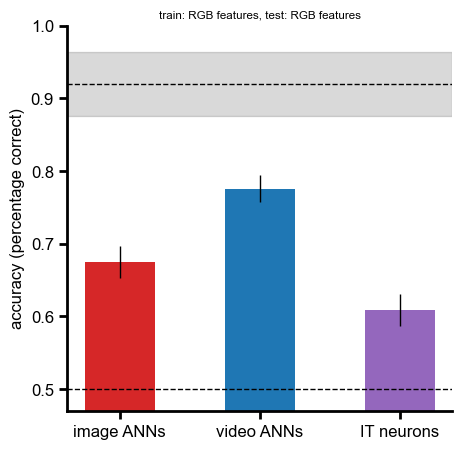

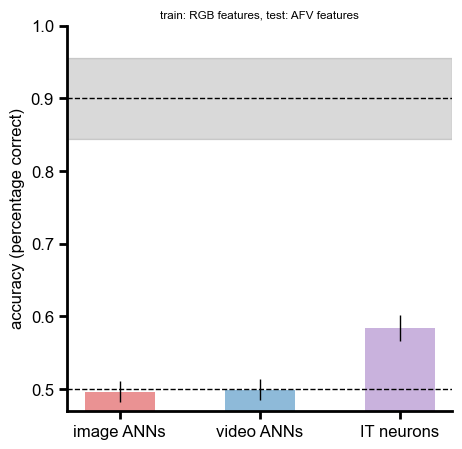

In [ ]:
# ============================================================================
# PLOT RGB->AFV DECODING: Summary bar plots comparing model types
# ============================================================================
n_static = len(static_models)
n_dynamic = len(dynamic_models)

# Calculate averages for static and dynamic models
static_rgb2afv_rgb = np.mean(values_rgb2afv_rgb[:n_static])
static_rgb2afv_afv = np.mean(values_rgb2afv_afv[:n_static])
dynamic_rgb2afv_rgb = np.mean(values_rgb2afv_rgb[n_static:])
dynamic_rgb2afv_afv = np.mean(values_rgb2afv_afv[n_static:])

static_rgb2afv_rgb_se = np.mean(errors_rgb2afv_rgb[:n_static])
static_rgb2afv_afv_se = np.mean(errors_rgb2afv_afv[:n_static])
dynamic_rgb2afv_rgb_se = np.mean(errors_rgb2afv_rgb[n_static:])
dynamic_rgb2afv_afv_se = np.mean(errors_rgb2afv_afv[n_static:])

# Plot RGB->AFV results for rgbinal (RGB) features
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(3)
width = 0.5

bars1 = ax.bar(x - width/2, [static_rgb2afv_rgb, dynamic_rgb2afv_rgb, np.nanmean(accuracy_per_time_rgb2afv_rgb_vid)], width, 
               yerr=[static_rgb2afv_rgb_se, dynamic_rgb2afv_rgb_se, np.nanstd(accuracy_per_time_rgb2afv_rgb_vid) / np.sqrt(accuracy_per_time_rgb2afv_rgb_vid.shape[0])],
               color=['tab:red', 'tab:blue', 'tab:purple'], capsize=0)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
plt.axhline(human_accouracy_mean[0], color='black', linestyle='--', linewidth=1)
plt.axhspan(human_accouracy_mean[0] - human_accouracy_std[0], human_accouracy_mean[0] + human_accouracy_std[0], color='black', alpha=0.15)

ax.set_ylabel('accuracy (percentage correct)', fontsize=12)
ax.set_xticks(x)
ax.set_ylim([0.47, 1.0])
plt.yticks(np.arange(0.5, 1.01, 0.1))
plt.xticks(np.concatenate([x - width/2]), ['image ANNs', 'video ANNs', 'IT neurons'])
plt.title(f"train: RGB features, test: RGB features")

journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_rgb2afv-rgb.pdf')
plt.show()

# Plot RGB->AFV results for AFV features
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(3)
width = 0.5

bars2 = ax.bar(x + width/2, [static_rgb2afv_afv, dynamic_rgb2afv_afv, np.nanmean(accuracy_per_time_rgb2afv_afv_vid)], width,
               yerr=[static_rgb2afv_afv_se, dynamic_rgb2afv_afv_se, np.nanstd(accuracy_per_time_rgb2afv_afv_vid) / np.sqrt(accuracy_per_time_rgb2afv_afv_vid.shape[0])],
               color=['tab:red', 'tab:blue', 'tab:purple'], capsize=0)

# Add transparency to indicate AFV features
bars2[0].set_alpha(0.5)
bars2[1].set_alpha(0.5)
bars2[2].set_alpha(0.5)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
plt.axhline(human_accouracy_mean[1], color='black', linestyle='--', linewidth=1)
plt.axhspan(human_accouracy_mean[1] - human_accouracy_std[1], human_accouracy_mean[1] + human_accouracy_std[1], color='black', alpha=0.15)

ax.set_ylabel('accuracy (percentage correct)', fontsize=12)
ax.set_xticks(x)
ax.set_ylim([0.47, 1.0])
plt.yticks(np.arange(0.5, 1.01, 0.1))
plt.xticks(np.concatenate([x + width/2]), ['image ANNs', 'video ANNs', 'IT neurons'])
plt.title(f"train: RGB features, test: AFV features")

journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_rgb2afv-afv.pdf')
plt.show()

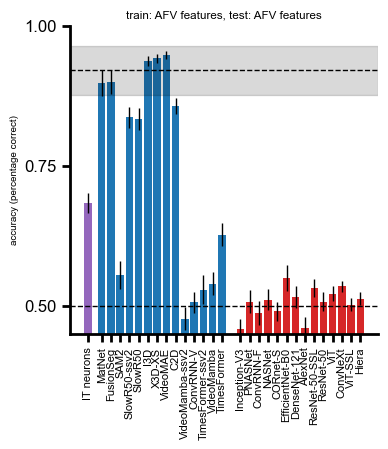

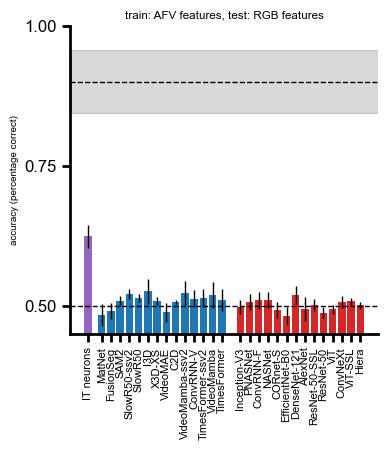

In [13]:

# ============================================================================
# PLOT AFV->RGB DECODING: Per-model bar plots
# ============================================================================
for p, phase in enumerate(['afv', 'rgb']):
    plt.figure(figsize=(4, 4))

    # Sort models by performance
    if phase == 'rgb':
        sorted_values = [values_afv2rgb_rgb[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_afv2rgb_rgb[i] for i in sorted_indices_rgb2afv]
    else:
        sorted_values = [values_afv2rgb_afv[i] for i in sorted_indices_rgb2afv]
        sorted_errors = [errors_afv2rgb_afv[i] for i in sorted_indices_rgb2afv]
    
    # Get labels for sorted models
    sorted_names = [methods_names[i] for i in sorted_indices_rgb2afv]
    sorted_labels = [models[name][2] for name in sorted_names]

    # Separate models into video and image groups
    video_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['d', 'rv']]
    image_indices = [i for i, name in enumerate(sorted_names) if models[name][0] in ['f', 'ri']]
    
    # Prepare bar plot data
    x_positions = []
    x_labels = []
    x_colors = []
    x_values = []
    x_errors = []
    
    pos = 0
    # Add IT neuron bar
    neurons_m = accuracy_per_time_afv2rgb_rgb_m if phase == 'rgb' else accuracy_per_time_afv2rgb_afv_m
    neurons_se = accuracy_per_time_afv2rgb_rgb_se if phase == 'rgb' else accuracy_per_time_afv2rgb_afv_se
    
    x_positions.append(pos)
    x_labels.append('IT neurons')
    x_colors.append('tab:purple')
    x_values.append(neurons_m)
    x_errors.append(neurons_se)
    pos += 1.5
    
    # Add video models (blue bars)
    for i in video_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:blue')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1
    
    pos += 1  # Gap between video and image models
    
    # Add image models (red bars)
    for i in image_indices:
        x_positions.append(pos)
        x_labels.append(sorted_labels[i])
        x_colors.append('tab:red')
        x_values.append(sorted_values[i])
        x_errors.append(sorted_errors[i])
        pos += 1
    
    # Create bar plot
    plt.bar(x_positions, x_values, yerr=x_errors, color=x_colors, width=0.8)
    plt.xticks(x_positions, x_labels)

    # Add reference lines
    plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
    plt.axhline(human_accouracy_mean[p], color='black', linestyle='--', linewidth=1)
    plt.axhspan(human_accouracy_mean[p] - human_accouracy_std[p], human_accouracy_mean[p] + human_accouracy_std[p], color='black', alpha=0.15)

    plt.ylabel("accuracy (percentage correct)")
    plt.xticks(rotation=90, fontsize=8)
    
    plt.ylim(0.45, 1)
    plt.yticks(np.arange(0.5, 1.01, 0.25))

    plt.title(f"train: AFV features, test: {'RGB' if phase == 'rgb' else 'AFV'} features")


    journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_afv2rgb-{phase}_barplot_grouped.pdf', fontsize_x=8)
    plt.show()


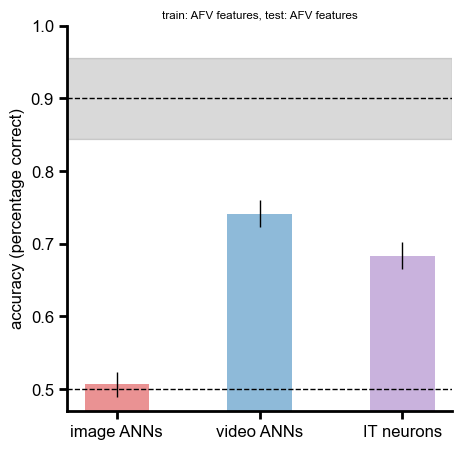

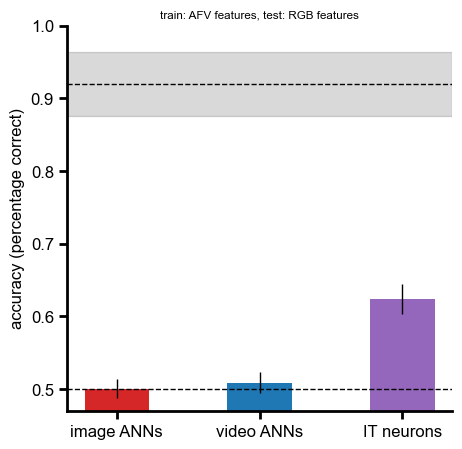

In [15]:
# ============================================================================
# PLOT AFV->RGB DECODING: Summary bar plots comparing model types
# ============================================================================
n_static = len(static_models)
n_dynamic = len(dynamic_models)

# Calculate averages for static and dynamic models
static_afv2rgb_rgb = np.mean(values_afv2rgb_rgb[:n_static])
static_afv2rgb_afv = np.mean(values_afv2rgb_afv[:n_static])
dynamic_afv2rgb_rgb = np.mean(values_afv2rgb_rgb[n_static:])
dynamic_afv2rgb_afv = np.mean(values_afv2rgb_afv[n_static:])

static_afv2rgb_rgb_se = np.mean(errors_afv2rgb_rgb[:n_static])
static_afv2rgb_afv_se = np.mean(errors_afv2rgb_afv[:n_static])
dynamic_afv2rgb_rgb_se = np.mean(errors_afv2rgb_rgb[n_static:])
dynamic_afv2rgb_afv_se = np.mean(errors_afv2rgb_afv[n_static:])

# Plot AFV->RGB results for AFV features
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(3)
width = 0.45

bars1 = ax.bar(x + width/2, [static_afv2rgb_afv, dynamic_afv2rgb_afv, np.nanmean(accuracy_per_time_afv2rgb_afv_vid)], width,
               yerr=[static_afv2rgb_afv_se, dynamic_afv2rgb_afv_se, np.nanstd(accuracy_per_time_afv2rgb_afv_vid) / np.sqrt(accuracy_per_time_afv2rgb_afv_vid.shape[0])],
               color=['tab:red', 'tab:blue', 'tab:purple'], capsize=0)

# Add transparency to indicate AFV features
bars1[0].set_alpha(0.5)
bars1[1].set_alpha(0.5)
bars1[2].set_alpha(0.5)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
plt.axhline(human_accouracy_mean[1], color='black', linestyle='--', linewidth=1)
plt.axhspan(human_accouracy_mean[1] - human_accouracy_std[1], human_accouracy_mean[1] + human_accouracy_std[1], color='black', alpha=0.15)

ax.set_ylabel('accuracy (percentage correct)', fontsize=12)
ax.set_xticks(x)
plt.xticks(np.concatenate([x + width/2]), ['image ANNs', 'video ANNs', 'IT neurons'])
ax.set_ylim([0.47, 1.0])
plt.yticks(np.arange(0.5, 1.01, 0.1))
plt.title(f"train: AFV features, test: AFV features")

journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_afv2rgb-afv.pdf')
plt.show()

# Plot AFV->RGB results for original (RGB) features
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(3)
width = 0.45

bars2 = ax.bar(x - width/2, [static_afv2rgb_rgb, dynamic_afv2rgb_rgb, np.nanmean(accuracy_per_time_afv2rgb_rgb_vid)], width, 
               yerr=[static_afv2rgb_rgb_se, dynamic_afv2rgb_rgb_se, np.nanstd(accuracy_per_time_afv2rgb_rgb_vid) / np.sqrt(accuracy_per_time_afv2rgb_rgb_vid.shape[0])],
               color=['tab:red', 'tab:blue', 'tab:purple'], capsize=0)

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
plt.axhline(human_accouracy_mean[0], color='black', linestyle='--', linewidth=1)
plt.axhspan(human_accouracy_mean[0] - human_accouracy_std[0], human_accouracy_mean[0] + human_accouracy_std[0], color='black', alpha=0.15)

ax.set_ylabel('accuracy (percentage correct)', fontsize=12)
ax.set_xticks(x)
plt.xticks(np.concatenate([x - width/2]), ['image ANNs', 'video ANNs', 'IT neurons'])
ax.set_ylim([0.47, 1.0])
plt.yticks(np.arange(0.5, 1.01, 0.1))
plt.title(f"train: AFV features, test: RGB features")

journal_figure_pdf(do_save=True, filename=f'../../plots/figure3_decode_obj_dir_rnn_afv2rgb-rgb.pdf')
plt.show()